# Notebook 06 — Explicación Profunda del Sistema BSAD

**Versión interactiva de `LEAME_PROFUNDO.md`**

Este notebook recorre el sistema completo con código ejecutable, visualizaciones y explicaciones detalladas en cada paso.

---

**Índice:**
1. El Problema — ¿por qué los datos de seguridad son difíciles?
2. Por qué fallan los métodos clásicos
3. El modelo Bayesiano Jerárquico — matemáticas y visualización
4. Pipeline de datos — de logs crudos a tabla de modelado
5. Scoring de anomalías — cómo funciona –log P(y | posterior)
6. Evaluación — métricas correctas vs incorrectas
7. Triage — del score al workflow SOC
8. Limitaciones honestas

> **Para generar todas las figuras en alta resolución:**
> ```bash
> python scripts/explain_pipeline.py --output outputs/explanation
> ```

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.special import logsumexp
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score

from bsad.data_generator import GeneratorConfig, generate_synthetic_data
from bsad.features import FeatureConfig, build_modeling_table, get_model_arrays
from bsad.model import ModelConfig, build_hierarchical_negbinom_model
from bsad.evaluation import compute_all_metrics, format_metrics_report

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

BLUE, RED, GREEN, ORANGE, GRAY = "#2E86AB", "#E84855", "#3BB273", "#F4A261", "#8D99AE"
RNG = np.random.default_rng(42)
print("✓ Setup completo")

✓ Setup completo


---
## 1. El Problema

> **Pregunta central:** ¿Por qué no basta con poner un umbral fijo de '15 eventos = sospechoso'?

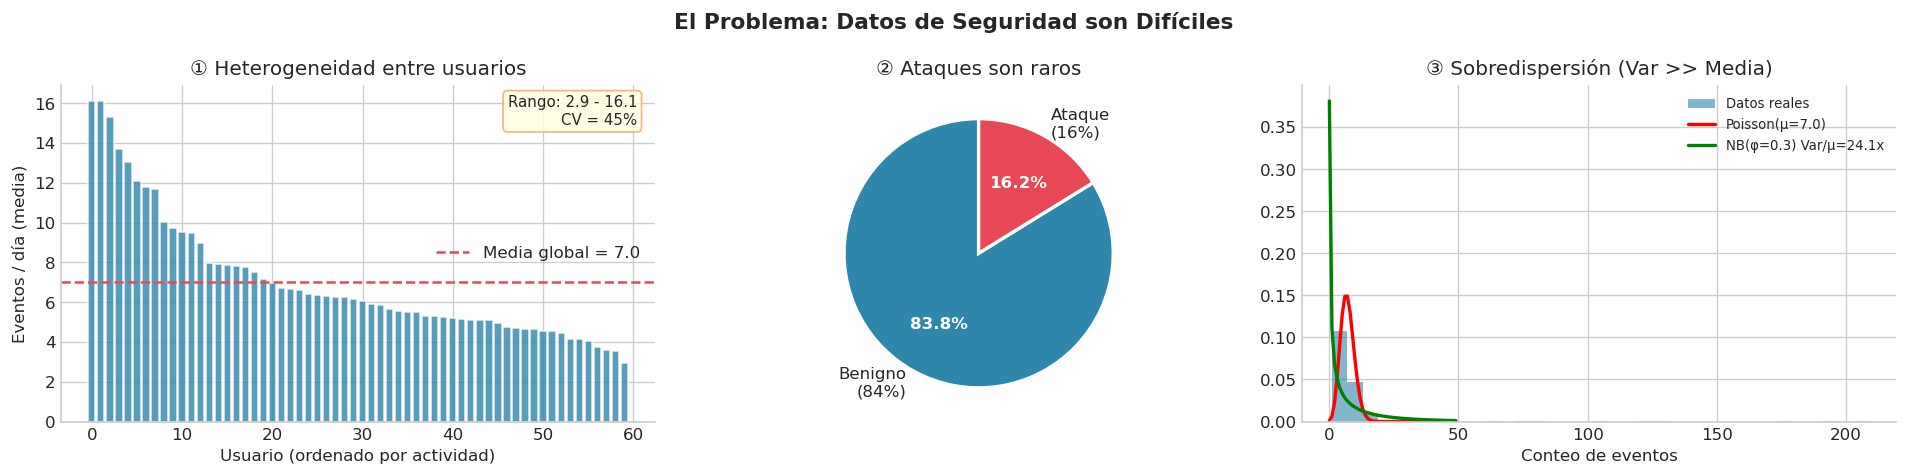


Datos generados: 1,185 ventanas | 60 entidades
Attack rate: 16.20% | Var/Media = 24.1x


In [2]:
# 1.1 Heterogeneidad de entidades
cfg = GeneratorConfig(n_users=60, n_days=21, attack_rate=0.03, random_seed=42)
events_df, _ = generate_synthetic_data(cfg)
modeling_df, meta = build_modeling_table(events_df, FeatureConfig())

user_means = modeling_df.groupby("user_id")["event_count"].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("El Problema: Datos de Seguridad son Difíciles", fontsize=13, fontweight="bold")

# Panel 1: Heterogeneidad
ax = axes[0]
ax.bar(range(len(user_means)), user_means.values, color=BLUE, alpha=0.8, edgecolor="white")
ax.axhline(user_means.mean(), color=RED, linestyle="--", lw=1.5,
           label=f"Media global = {user_means.mean():.1f}")
ax.set_title("① Heterogeneidad entre usuarios")
ax.set_xlabel("Usuario (ordenado por actividad)")
ax.set_ylabel("Eventos / día (media)")
ax.legend()
ax.text(0.97, 0.97,
        f"Rango: {user_means.min():.1f} - {user_means.max():.1f}\nCV = {user_means.std()/user_means.mean():.0%}",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec=ORANGE, alpha=0.8))

# Panel 2: Rareza
ax = axes[1]
ar = meta["attack_rate"]
sizes = [1 - ar, ar]
wedges, _, autotexts = ax.pie(sizes,
    labels=[f"Benigno\n({1-ar:.0%})", f"Ataque\n({ar:.0%})"],
    colors=[BLUE, RED], autopct="%1.1f%%", startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=2), pctdistance=0.6)
for at in autotexts:
    at.set_fontsize(10); at.set_fontweight("bold"); at.set_color("white")
ax.set_title("② Ataques son raros")

# Panel 3: Sobredispersión
ax = axes[2]
counts = modeling_df["event_count"].values
mu = counts.mean(); var = counts.var()
x = np.arange(0, min(int(counts.max()) + 1, 50))
ax.hist(counts, bins=35, density=True, alpha=0.6, color=BLUE, label="Datos reales")
ax.plot(x, stats.poisson.pmf(x, mu=mu), "r-", lw=2, label=f"Poisson(μ={mu:.1f})")
phi = mu**2 / max(var - mu, 0.1)
ax.plot(x, stats.nbinom.pmf(x, n=phi, p=phi/(phi+mu)), "g-", lw=2,
        label=f"NB(φ={phi:.1f}) Var/μ={var/mu:.1f}x")
ax.set_title("③ Sobredispersión (Var >> Media)")
ax.set_xlabel("Conteo de eventos"); ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nDatos generados: {len(modeling_df):,} ventanas | {meta['n_entities']} entidades")
print(f"Attack rate: {meta['attack_rate']:.2%} | Var/Media = {var/mu:.1f}x")

---
## 2. Por qué fallan los métodos clásicos

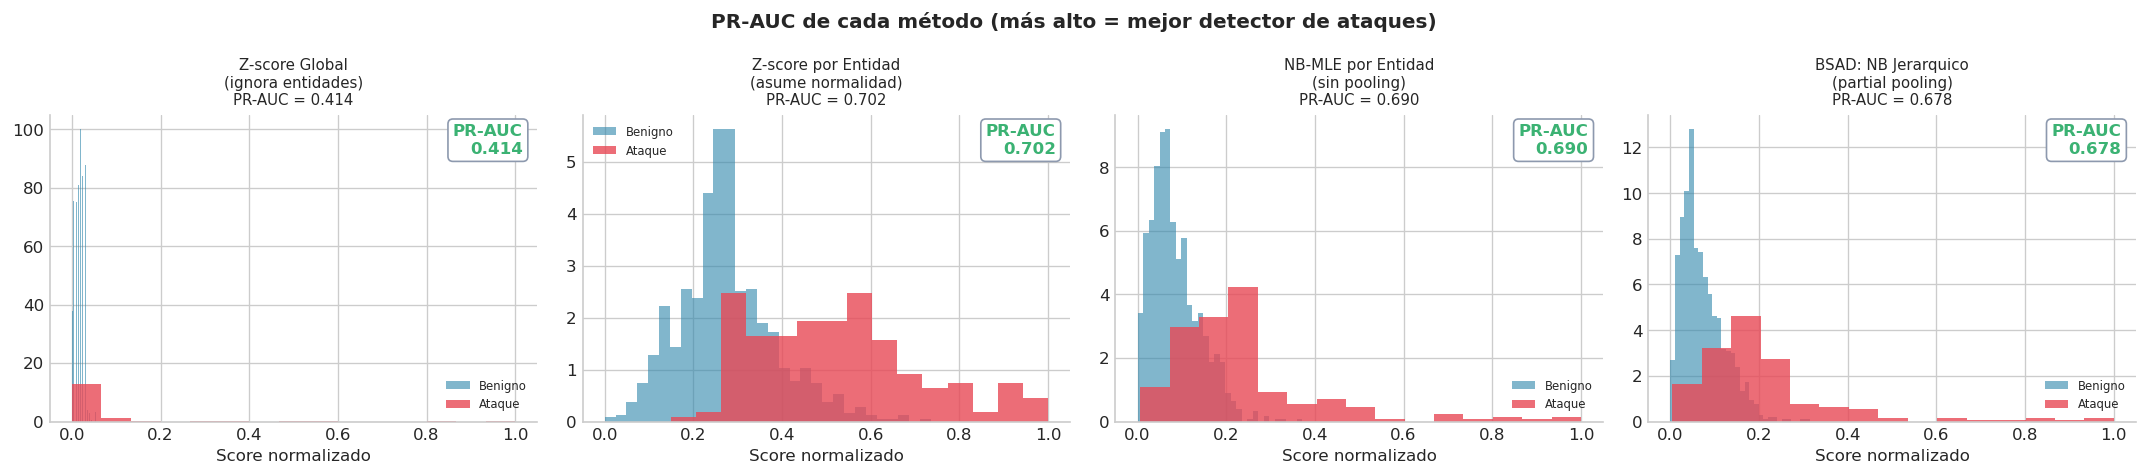

In [3]:
# Comparar Z-score global, Z-score entidad, NB-MLE, y NB aproximado con pooling
y_all = modeling_df["event_count"].values
entity_idx = modeling_df["entity_idx"].values
is_attack  = modeling_df["has_attack"].astype(int).values
n_entities = meta["n_entities"]

# 1. Z-score global
g_mean, g_std = y_all.mean(), y_all.std()
score_z_global = np.abs((y_all - g_mean) / (g_std + 1e-8))

# 2. Z-score por entidad
score_z_entity = np.zeros(len(y_all))
for e in range(n_entities):
    mask = entity_idx == e
    mu_e = y_all[mask].mean(); std_e = max(y_all[mask].std(), 0.5)
    score_z_entity[mask] = (y_all[mask] - mu_e) / std_e

# 3. NB-MLE por entidad
score_nb_mle = np.zeros(len(y_all))
for e in range(n_entities):
    mask = entity_idx == e
    mu_e = y_all[mask].mean(); var_e = y_all[mask].var()
    phi_e = max(mu_e**2 / max(var_e - mu_e, 0.1), 0.5)
    p_e = phi_e / (phi_e + mu_e)
    score_nb_mle[mask] = -stats.nbinom.logpmf(y_all[mask], n=phi_e, p=p_e)

# 4. NB con partial pooling (simulado)
score_bsad = np.zeros(len(y_all))
k = 5
for e in range(n_entities):
    mask = entity_idx == e
    mu_e = y_all[mask].mean(); n_e = mask.sum()
    mu_s = (n_e * mu_e + k * g_mean) / (n_e + k)
    phi_e = max(mu_e**2 / max(y_all[mask].var() - mu_e, 0.1), 0.5)
    p_e = phi_e / (phi_e + mu_s)
    score_bsad[mask] = -stats.nbinom.logpmf(y_all[mask], n=phi_e, p=p_e)

methods = [
    ("Z-score Global\n(ignora entidades)", score_z_global),
    ("Z-score por Entidad\n(asume normalidad)", score_z_entity),
    ("NB-MLE por Entidad\n(sin pooling)", score_nb_mle),
    ("BSAD: NB Jerarquico\n(partial pooling)", score_bsad),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle("PR-AUC de cada método (más alto = mejor detector de ataques)", fontsize=12, fontweight="bold")

for ax, (title, scores) in zip(axes, methods):
    pr_auc = average_precision_score(is_attack, scores)
    s_norm = (scores - scores.min()) / (scores.max() - scores.min() + 1e-8)
    ax.hist(s_norm[is_attack == 0], bins=30, alpha=0.6, color=BLUE, density=True, label="Benigno")
    ax.hist(s_norm[is_attack == 1], bins=15, alpha=0.8, color=RED, density=True, label="Ataque")
    ax.set_title(f"{title}\nPR-AUC = {pr_auc:.3f}", fontsize=9)
    ax.set_xlabel("Score normalizado"); ax.legend(fontsize=7)
    c = GREEN if pr_auc > 0.15 else RED
    ax.text(0.97, 0.97, f"PR-AUC\n{pr_auc:.3f}", transform=ax.transAxes,
            ha="right", va="top", fontsize=10, fontweight="bold", color=c,
            bbox=dict(boxstyle="round", fc="white", ec=GRAY))

plt.tight_layout()
plt.show()

---
## 3. El Modelo Bayesiano Jerárquico

### 3.1 La estructura matemática

```
Población:    μ ~ Exp(0.1)          # tasa media global
              α ~ HalfNormal(2)     # concentración

Entidad:      θ_e ~ Gamma(μα, α)    # tasa propia de cada entidad

Observación:  φ ~ HalfNormal(2)     # sobredispersión
              y ~ NegBin(θ_{e_n}, φ)  # dato observado
```

El score de anomalía: `–log p(y | posterior)` = cuán improbable es y bajo el modelo aprendido.

In [4]:
# 3.2 Construcción del modelo (sin entrenar — solo la estructura)
import pymc as pm

arrays = get_model_arrays(modeling_df)
config = ModelConfig(n_samples=100, n_tune=50, n_chains=2, random_seed=42)

model = build_hierarchical_negbinom_model(
    y=arrays["y"],
    entity_idx=arrays["entity_idx"],
    n_entities=arrays["n_entities"],
    config=config,
)

print("Variables del modelo:")
print([v.name for v in model.free_RVs])
print()
print(f"Entidades modeladas: {arrays['n_entities']}")
print(f"Observaciones:       {len(arrays['y'])}")
print()
print("Estructura jerárquica:")
print("  μ, α  → parámetros de POBLACIÓN")
print("  θ_e   → parámetros de ENTIDAD (uno por usuario)")
print("  φ     → sobredispersión GLOBAL")
print("  y_n   → DATO OBSERVADO (likelihood)")

Variables del modelo:
['mu', 'alpha', 'theta', 'phi']

Entidades modeladas: 60
Observaciones:       1185

Estructura jerárquica:
  μ, α  → parámetros de POBLACIÓN
  θ_e   → parámetros de ENTIDAD (uno por usuario)
  φ     → sobredispersión GLOBAL
  y_n   → DATO OBSERVADO (likelihood)


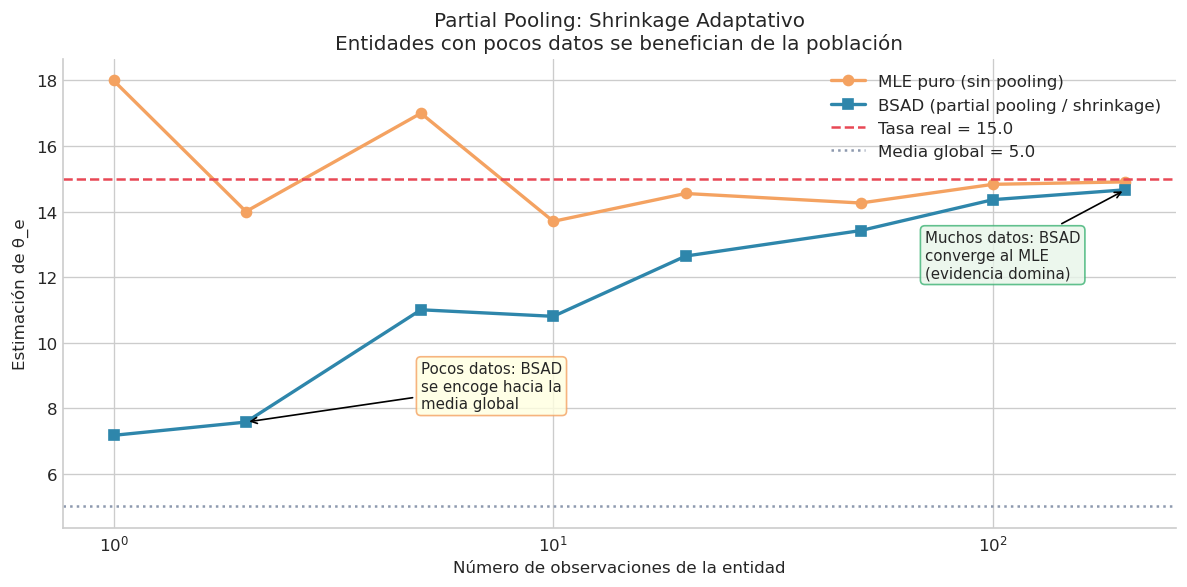

In [5]:
# 3.3 Visualización del partial pooling
fig, ax = plt.subplots(figsize=(10, 5))

n_obs_range = [1, 2, 5, 10, 20, 50, 100, 200]
true_rate = 15.0
global_mean_val = 5.0
k_shrink = 5

mle_vals, bayes_vals = [], []
for n in n_obs_range:
    obs_sim = RNG.poisson(true_rate, size=n)
    mle = obs_sim.mean()
    bsad = (n * mle + k_shrink * global_mean_val) / (n + k_shrink)
    mle_vals.append(mle)
    bayes_vals.append(bsad)

ax.plot(n_obs_range, mle_vals,   "o-", color=ORANGE, lw=2, markersize=6,
        label="MLE puro (sin pooling)")
ax.plot(n_obs_range, bayes_vals, "s-", color=BLUE,   lw=2, markersize=6,
        label="BSAD (partial pooling / shrinkage)")
ax.axhline(true_rate,       color=RED,  linestyle="--", lw=1.5, label=f"Tasa real = {true_rate}")
ax.axhline(global_mean_val, color=GRAY, linestyle=":",  lw=1.5, label=f"Media global = {global_mean_val}")

ax.annotate("Pocos datos: BSAD\nse encoge hacia la\nmedia global",
            xy=(2, bayes_vals[1]), xytext=(5, 8),
            arrowprops=dict(arrowstyle="->", color="black"),
            fontsize=9, bbox=dict(boxstyle="round", fc="lightyellow", ec=ORANGE, alpha=0.8))
ax.annotate("Muchos datos: BSAD\nconverge al MLE\n(evidencia domina)",
            xy=(200, bayes_vals[-1]), xytext=(70, 12),
            arrowprops=dict(arrowstyle="->", color="black"),
            fontsize=9, bbox=dict(boxstyle="round", fc="#E8F5E9", ec=GREEN, alpha=0.8))

ax.set_xscale("log")
ax.set_xlabel("Número de observaciones de la entidad")
ax.set_ylabel("Estimación de θ_e")
ax.set_title("Partial Pooling: Shrinkage Adaptativo\nEntidades con pocos datos se benefician de la población")
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Pipeline de datos

De logs crudos a tabla de modelado paso a paso.

In [6]:
print("PASO 1: Eventos crudos")
print(events_df[["timestamp", "user_id", "ip_address", "endpoint",
                   "status_code", "is_attack", "attack_type"]].head(5).to_string(index=False))

print("\nPASO 2: Agregado por ventanas de 1 día")
from bsad.features import create_time_windows
windowed = create_time_windows(events_df, FeatureConfig(window_size="1D"))
print(windowed[["user_id", "window", "event_count", "unique_ips",
                 "unique_devices", "has_attack"]].head(5).to_string(index=False))

print(f"\nTotal filas en eventos:   {len(events_df):,}")
print(f"Total filas en windowed:  {len(windowed):,}  ← una por (usuario, día)")
print(f"Sum event_count:          {windowed['event_count'].sum():,} == {len(events_df):,}  ✓ (sin pérdida)")

PASO 1: Eventos crudos
          timestamp   user_id     ip_address      endpoint  status_code  is_attack         attack_type
2024-01-01 00:29:55 user_0046 attack_ip_8145 /api/v1/login          401       True credential_stuffing
2024-01-01 00:31:49 user_0056 attack_ip_8145 /api/v1/login          401       True credential_stuffing
2024-01-01 00:41:13 user_0042 attack_ip_8145 /api/v1/login          401       True credential_stuffing
2024-01-01 00:51:55 user_0031 attack_ip_8145 /api/v1/login          401       True credential_stuffing
2024-01-01 01:02:45 user_0044 attack_ip_8145 /api/v1/login          200       True credential_stuffing

PASO 2: Agregado por ventanas de 1 día
  user_id     window  event_count  unique_ips  unique_devices  has_attack
user_0000 2024-01-01            5           3               2       False
user_0000 2024-01-03            6           1               2       False
user_0000 2024-01-04            7           3               6        True
user_0000 2024-01-05   

In [7]:
print("PASO 3: Features de entidad (ATENCIÓN AL LEAKAGE)")
print()
print("✓ CORRECTO para ENTRENAMIENTO:")
print("  add_entity_features(train_windowed, entity_col)")
print("  → calcula mean/std/zscore SOLO sobre datos de train")
print()
print("✗ INCORRECTO (lo que hace el pipeline naive):")
print("  add_entity_features(train_windowed + test_windowed)")
print("  → contamina las estadísticas del train con el futuro")
print()
print("PASO 4: Encoding de entidades")
from bsad.features import encode_entity_ids
from bsad.features import add_entity_features
windowed2 = add_entity_features(windowed, "user_id")
encoded, entity_map = encode_entity_ids(windowed2, "user_id")
print(f"  Entidades únicas: {len(entity_map)}")
print(f"  Rango de entity_idx: [{encoded['entity_idx'].min()}, {encoded['entity_idx'].max()}]  ← contiguos [0, E)")
print()
print("PASO 5: Arrays para PyMC")
arrays = get_model_arrays(encoded)
print(f"  y.shape:          {arrays['y'].shape}  dtype={arrays['y'].dtype}")
print(f"  entity_idx.shape: {arrays['entity_idx'].shape}  dtype={arrays['entity_idx'].dtype}")
print(f"  n_entities:       {arrays['n_entities']}")
print(f"  is_attack.sum():  {arrays['is_attack'].sum()}  ← NO entra al modelo, solo evaluación")

PASO 3: Features de entidad (ATENCIÓN AL LEAKAGE)

✓ CORRECTO para ENTRENAMIENTO:
  add_entity_features(train_windowed, entity_col)
  → calcula mean/std/zscore SOLO sobre datos de train

✗ INCORRECTO (lo que hace el pipeline naive):
  add_entity_features(train_windowed + test_windowed)
  → contamina las estadísticas del train con el futuro

PASO 4: Encoding de entidades
  Entidades únicas: 60
  Rango de entity_idx: [0, 59]  ← contiguos [0, E)

PASO 5: Arrays para PyMC
  y.shape:          (1185,)  dtype=int64
  entity_idx.shape: (1185,)  dtype=int64
  n_entities:       60
  is_attack.sum():  192  ← NO entra al modelo, solo evaluación


---
## 5. Scoring de Anomalías

`score = –log p(y | posterior)` — un evento es anómalo si es **improbable bajo la distribución aprendida de su entidad**.

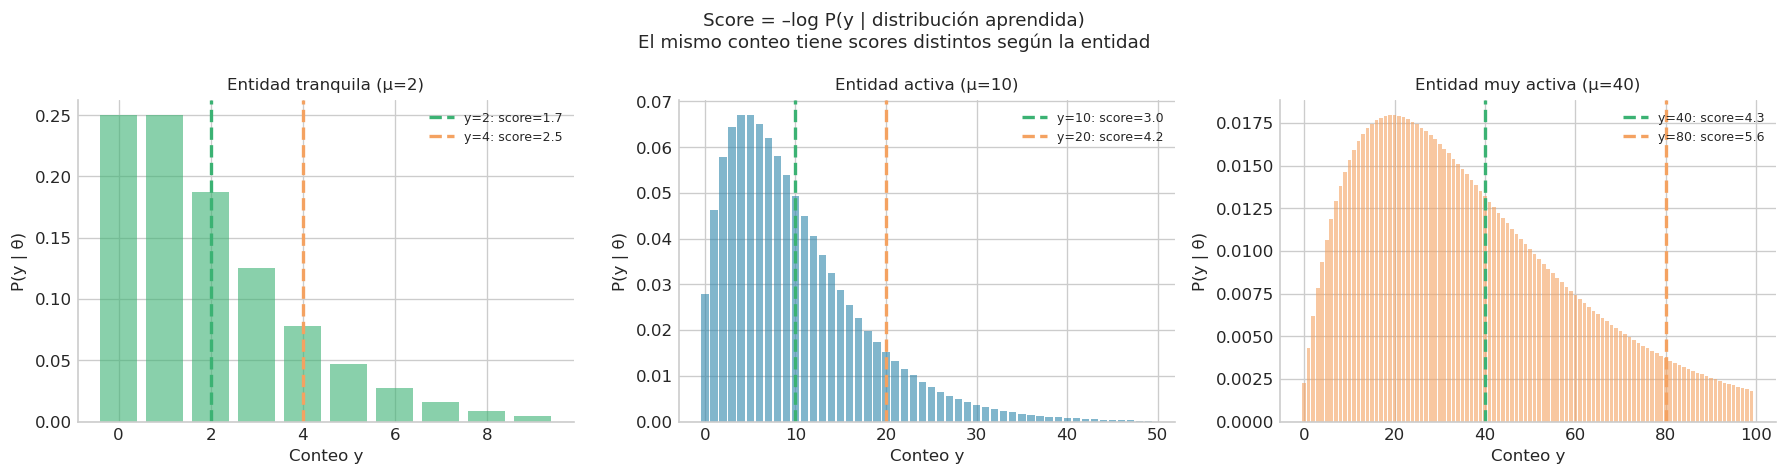

In [8]:
# Visualización: P(y | theta) para tres entidades distintas
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Score = –log P(y | distribución aprendida)\nEl mismo conteo tiene scores distintos según la entidad", fontsize=11)

for ax, (mu_e, label, color) in zip(axes, [
    (2.0,  "Entidad tranquila (μ=2)",     GREEN),
    (10.0, "Entidad activa (μ=10)",       BLUE),
    (40.0, "Entidad muy activa (μ=40)", ORANGE),
]):
    phi_e = 2.0
    p_e   = phi_e / (phi_e + mu_e)
    x_max = int(mu_e * 5)
    x     = np.arange(0, min(x_max, 100))
    pmf   = stats.nbinom.pmf(x, n=phi_e, p=p_e)

    ax.bar(x, pmf, color=color, alpha=0.6)

    # Marcar tres puntos: normal, medio, alto
    for y_obs, marker, mc in [(int(mu_e), "normal", GREEN),
                               (int(mu_e * 2), "elevado", ORANGE),
                               (int(mu_e * 5), "muy alto", RED)]:
        if y_obs < len(x):
            sc = -stats.nbinom.logpmf(y_obs, n=phi_e, p=p_e)
            ax.axvline(y_obs, color=mc, lw=2, linestyle="--",
                       label=f"y={y_obs}: score={sc:.1f}")

    ax.set_title(label, fontsize=10)
    ax.set_xlabel("Conteo y")
    ax.set_ylabel("P(y | θ)")
    ax.legend(fontsize=7.5)

plt.tight_layout()
plt.show()

In [9]:
# Cómo funciona la marginalizacion sobre el posterior
# (sin MCMC real, simulamos muestras posteriores)
print("Simulación de marginalizacion sobre el posterior:")
print()

n_post = 500
mu_pop, alpha_pop = 5.0, 3.0
theta_samples = RNG.gamma(shape=mu_pop * alpha_pop, scale=1.0 / alpha_pop, size=n_post)
phi_samples   = RNG.exponential(scale=2.0, size=n_post)

y_obs_list = [3, 8, 25, 60]

print(f"{'y observado':>12} {'Score promedio':>15} {'Score std':>12} {'Interpretación':>25}")
print("-" * 68)
for y_obs in y_obs_list:
    per_sample = np.array([
        -stats.nbinom.logpmf(y_obs, n=phi_s, p=phi_s/(phi_s+theta_s))
        for theta_s, phi_s in zip(theta_samples, phi_samples)
    ])
    # Promedio en escala log (log-sum-exp)
    log_sum = logsumexp(-per_sample)
    avg_score = -(log_sum - np.log(n_post))

    interp = "Muy probable" if avg_score < 4 else ("Posible" if avg_score < 8 else ("Sospechoso" if avg_score < 15 else "Anomalía clara"))
    print(f"{y_obs:>12} {avg_score:>15.2f} {per_sample.std():>12.2f} {interp:>25}")

Simulación de marginalizacion sobre el posterior:

 y observado  Score promedio    Score std            Interpretación
--------------------------------------------------------------------
           3            2.33         0.61              Muy probable
           8            3.29         0.67              Muy probable
          25            6.49         2.95                   Posible
          60            9.31        11.16                Sospechoso


---
## 6. Evaluación: métricas correctas para eventos raros

In [10]:
# Generar scores para evaluación
def approx_score(row):
    mu_e  = max(row["entity_mean_count"], 0.5)
    std_e = max(row["entity_std_count"], 0.5)
    phi_e = max(mu_e**2 / max(std_e**2 - mu_e, 0.1), 0.5)
    p_e   = phi_e / (phi_e + mu_e)
    return float(-stats.nbinom.logpmf(int(row["event_count"]), n=phi_e, p=p_e))

modeling_df["score"] = modeling_df.apply(approx_score, axis=1)
y_true = modeling_df["has_attack"].astype(int).values
scores = modeling_df["score"].values

metrics = compute_all_metrics(y_true, scores, k_values=[10, 25, 50, 100])
print(format_metrics_report(metrics))

PR-AUC:         0.697
ROC-AUC:        0.876
Attack rate:    16.20%
Observations:   1,185
Positives:      192
Recall@10      0.052
Recall@25      0.130
Recall@50      0.229
Recall@100     0.438
Precision@10    1.000
Precision@25    1.000
Precision@50    0.880
Precision@100   0.840


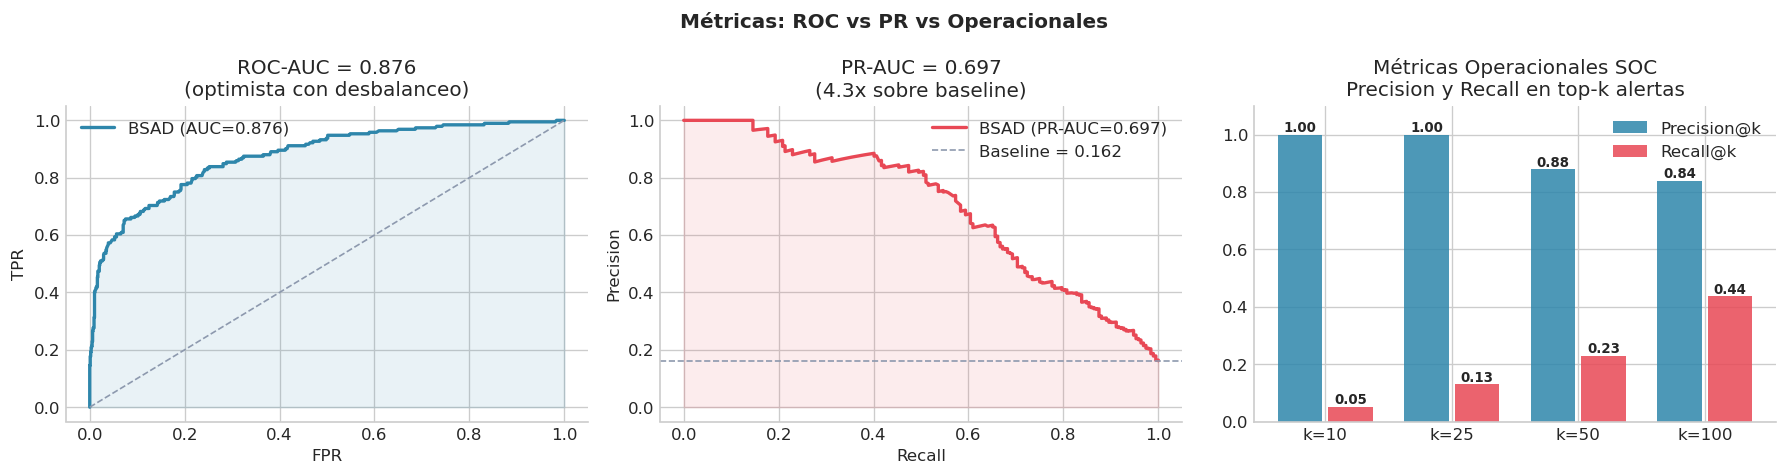

In [11]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Métricas: ROC vs PR vs Operacionales", fontsize=12, fontweight="bold")

# ROC
ax = axes[0]
fpr_r, tpr_r, _ = roc_curve(y_true, scores)
ax.plot(fpr_r, tpr_r, color=BLUE, lw=2, label=f"BSAD (AUC={metrics['roc_auc']:.3f})")
ax.plot([0,1],[0,1], color=GRAY, linestyle="--", lw=1)
ax.fill_between(fpr_r, tpr_r, alpha=0.1, color=BLUE)
ax.set_title(f"ROC-AUC = {metrics['roc_auc']:.3f}\n(optimista con desbalanceo)")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.legend()

# PR
ax = axes[1]
prec_c, rec_c, _ = precision_recall_curve(y_true, scores)
ax.plot(rec_c, prec_c, color=RED, lw=2, label=f"BSAD (PR-AUC={metrics['pr_auc']:.3f})")
ax.axhline(y_true.mean(), color=GRAY, linestyle="--", lw=1,
           label=f"Baseline = {y_true.mean():.3f}")
ax.fill_between(rec_c, prec_c, alpha=0.1, color=RED)
ax.set_title(f"PR-AUC = {metrics['pr_auc']:.3f}\n({metrics['pr_auc']/y_true.mean():.1f}x sobre baseline)")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.legend()

# Precision@k / Recall@k
ax = axes[2]
ks  = [10, 25, 50, 100]
prk = [metrics.get(f"precision_at_{k}", 0) for k in ks]
rek = [metrics.get(f"recall_at_{k}", 0) for k in ks]
x   = np.arange(len(ks))
ax.bar(x - 0.2, prk, 0.35, color=BLUE,  alpha=0.85, label="Precision@k")
ax.bar(x + 0.2, rek, 0.35, color=RED,   alpha=0.85, label="Recall@k")
for i, (p, r) in enumerate(zip(prk, rek)):
    ax.text(i-0.2, p+0.01, f"{p:.2f}", ha="center", fontsize=8, fontweight="bold")
    ax.text(i+0.2, r+0.01, f"{r:.2f}", ha="center", fontsize=8, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels([f"k={k}" for k in ks])
ax.set_ylim(0, 1.1)
ax.set_title("Métricas Operacionales SOC\nPrecision y Recall en top-k alertas")
ax.legend()

plt.tight_layout()
plt.show()

---
## 7. Triage: del score al workflow SOC

In [12]:
from triage.risk_score import RiskScorer
from triage.calibrate_thresholds import AlertBudget, build_alert_budget_curve
from triage.ranking_metrics import precision_at_k, recall_at_k

# Risk Score compuesto
entity_obs = modeling_df.groupby("user_id")["event_count"].count()
obs_counts = modeling_df["user_id"].map(entity_obs).values

scorer = RiskScorer(score_weight=0.5, confidence_weight=0.3, novelty_weight=0.2)
score_std = scores * 0.15 + RNG.exponential(0.3, len(scores))
risk_scores = scorer.compute(scores, score_std, obs_counts)
modeling_df["risk_score"] = risk_scores

# Calibración de umbral para 30 alertas/día
budget = AlertBudget(mode="fixed_alerts", target=30)
result = budget.calibrate(scores, y_true, n_windows_per_day=500)
threshold = result["threshold"]

print(f"Budget: 30 alertas/día")
print(f"  Umbral calibrado:  {threshold:.2f}")
print(f"  Recall obtenido:   {result.get('recall', 0):.1%}")
print(f"  FPR:               {result.get('fpr', 0):.1%}")
print()

top10 = modeling_df.nlargest(10, "risk_score")[
    ["user_id", "event_count", "entity_mean_count", "score", "risk_score", "has_attack"]
].round(2)
print("Top 10 alertas priorizadas por Risk Score:")
print(top10.to_string(index=False))

Budget: 30 alertas/día
  Umbral calibrado:  4.04
  Recall obtenido:   32.3%
  FPR:               1.0%

Top 10 alertas priorizadas por Risk Score:
  user_id  event_count  entity_mean_count  score  risk_score  has_attack
user_0000          209              16.11  11.38        0.69        True
user_0027          196              16.10  10.96        0.67        True
user_0019          176              15.30  10.54        0.65        True
user_0054          128              11.78   9.92        0.64        True
user_0015          123              11.67   9.74        0.64        True
user_0001           75               7.88   8.76        0.61        True
user_0048          126              13.05   9.38        0.58        True
user_0033          105              13.71   8.34        0.58        True
user_0006           81               9.72   8.34        0.55        True
user_0033           66              13.71   6.71        0.51        True


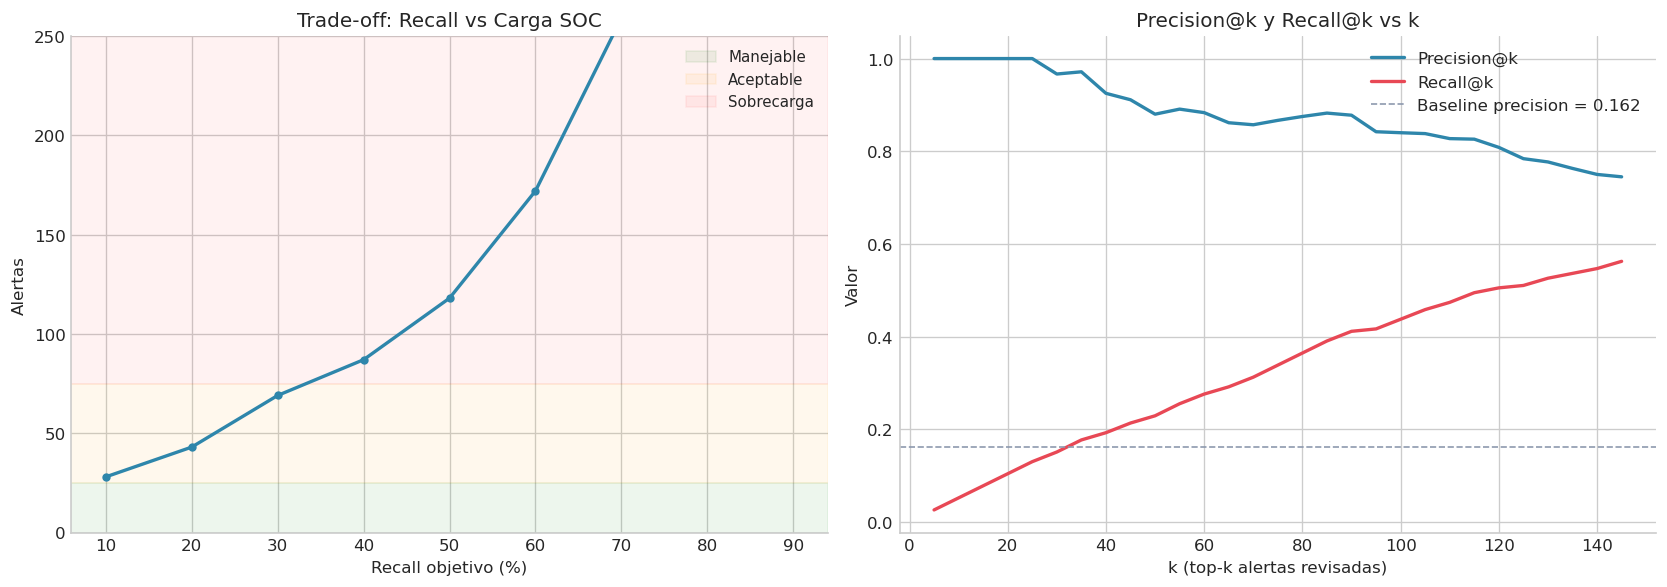

In [13]:
# Curva budget completa
budget_curve = build_alert_budget_curve(scores, y_true)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(budget_curve["target_recall"] * 100, budget_curve["alerts"],
        "o-", color=BLUE, lw=2, markersize=4)
ax.axhspan(0,  25, alpha=0.07, color="green",  label="Manejable")
ax.axhspan(25, 75, alpha=0.07, color="orange", label="Aceptable")
ax.axhspan(75, 500, alpha=0.05, color="red",   label="Sobrecarga")
ax.set_xlabel("Recall objetivo (%)")
ax.set_ylabel("Alertas")
ax.set_title("Trade-off: Recall vs Carga SOC")
ax.set_ylim(0, 250); ax.legend(fontsize=9)

ax = axes[1]
ks_range = range(5, min(len(y_true), 150), 5)
precs = [precision_at_k(y_true, scores, k) for k in ks_range]
recs  = [recall_at_k(y_true, scores, k) for k in ks_range]
ax.plot(list(ks_range), precs, color=BLUE, lw=2, label="Precision@k")
ax.plot(list(ks_range), recs,  color=RED,  lw=2, label="Recall@k")
ax.axhline(y_true.mean(), color=GRAY, linestyle="--", lw=1,
           label=f"Baseline precision = {y_true.mean():.3f}")
ax.set_xlabel("k (top-k alertas revisadas)")
ax.set_ylabel("Valor")
ax.set_title("Precision@k y Recall@k vs k")
ax.legend()

plt.tight_layout()
plt.show()

---
## 8. Limitaciones Honestas

In [14]:
# Demostración de qué detecta y qué no detecta el modelo

# Generar un usuario con solo una "geo_anomaly" sutil (5 eventos extra)
mu_user_normal = 8.0  # baseline del usuario

# Caso A: brute_force — 150 eventos en un día (normal = 8)
y_bf = 150
score_bf = -stats.nbinom.logpmf(y_bf, n=2, p=2/(2+mu_user_normal))

# Caso B: geo_anomaly — 5 eventos extra desde ubicación sospechosa
y_geo = 12  # solo 4 más que la media
score_geo = -stats.nbinom.logpmf(y_geo, n=2, p=2/(2+mu_user_normal))

# Caso C: device_anomaly — 2 accesos desde dispositivo nuevo
y_dev = 10
score_dev = -stats.nbinom.logpmf(y_dev, n=2, p=2/(2+mu_user_normal))

# Umbral típico basado en percentil 95
threshold_95 = np.percentile(modeling_df["score"], 95)

print("Tipo de ataque     | y observado | Score NB  | > umbral?    | Detectable?")
print("-" * 78)
for name, y_a, sc in [("brute_force",   y_bf,  score_bf),
                       ("geo_anomaly",   y_geo, score_geo),
                       ("device_anomaly",y_dev, score_dev)]:
    above = "SI" if sc > threshold_95 else "NO"
    detectable = "Muy alta" if sc > threshold_95 * 2 else ("Media" if sc > threshold_95 else "Baja")
    print(f"{name:<18} | {y_a:<11} | {sc:>9.2f} | {above:<12} | {detectable}")

print(f"\nUmbral (percentil 95): {threshold_95:.2f}")
print()
print("CONCLUSIÓN:")
print("  El modelo NB detecta VOLUMEN anómalo, no comportamiento multivariado.")
print("  geo_anomaly y device_anomaly solo se detectan si elevan event_count.")
print("  Para detectar geo/device, necesitarías features adicionales en el likelihood.")

Tipo de ataque     | y observado | Score NB  | > umbral?    | Detectable?
------------------------------------------------------------------------------
brute_force        | 150         |     31.67 | SI           | Muy alta
geo_anomaly        | 12          |      3.33 | NO           | Baja
device_anomaly     | 10          |      3.05 | NO           | Baja

Umbral (percentil 95): 4.21

CONCLUSIÓN:
  El modelo NB detecta VOLUMEN anómalo, no comportamiento multivariado.
  geo_anomaly y device_anomaly solo se detectan si elevan event_count.
  Para detectar geo/device, necesitarías features adicionales en el likelihood.


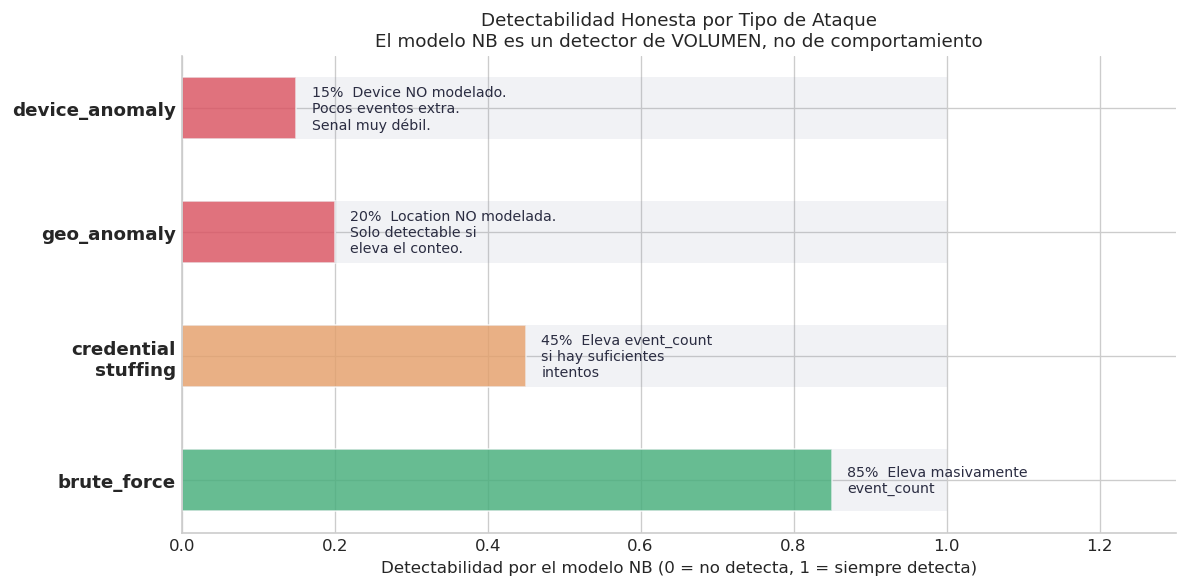

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

attack_types = ["brute_force", "credential\nstuffing", "geo_anomaly", "device_anomaly"]
detectability = [0.85, 0.45, 0.20, 0.15]
colors_d = [GREEN if d > 0.5 else (ORANGE if d > 0.3 else RED) for d in detectability]
mechanisms = [
    "Eleva masivamente\nevent_count",
    "Eleva event_count\nsi hay suficientes\nintentos",
    "Location NO modelada.\nSolo detectable si\neleva el conteo.",
    "Device NO modelado.\nPocos eventos extra.\nSenal muy débil.",
]

y_pos = range(len(attack_types))
bars = ax.barh(y_pos, detectability, color=colors_d, alpha=0.8, edgecolor="white", height=0.5)
ax.barh(y_pos, [1.0]*len(attack_types), color=GRAY, alpha=0.12, height=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(attack_types, fontsize=11, fontweight="bold")
ax.set_xlabel("Detectabilidad por el modelo NB (0 = no detecta, 1 = siempre detecta)")
ax.set_title("Detectabilidad Honesta por Tipo de Ataque\nEl modelo NB es un detector de VOLUMEN, no de comportamiento", fontsize=11)
ax.set_xlim(0, 1.3)

for i, (bar, mech) in enumerate(zip(bars, mechanisms)):
    ax.text(bar.get_width() + 0.02, i, f"{bar.get_width():.0%}  {mech}",
            va="center", fontsize=8.5, color="#2B2D42")

plt.tight_layout()
plt.show()

---
## Resumen Final

| Capa | Módulo clave | Qué hace | Limitación |
|---|---|---|---|
| **Datos** | `bsad.data_generator` | Genera eventos sintéticos con 4 tipos de ataque | geo/device solo detectables via conteo |
| **Features** | `bsad.features` | Agrega eventos → conteos por entidad-ventana | `entity_mean_count` tiene riesgo de leakage |
| **Modelo** | `bsad.model` | NB jerárquico con partial pooling vía MCMC | Entrenamiento lento (horas) |
| **Scoring** | `bsad.scoring` | `–log p(y│posterior)` con incertidumbre | Loop Python lento para posteriors grandes |
| **Evaluación** | `bsad.evaluation` | PR-AUC, Recall@k, Precision@k | Metrics sobre datos sintéticos pueden ser optimistas |
| **Triage** | `triage/` | Risk Score + Alert Budget + Contexto de entidad | Pesos del Risk Score son heurísticos |

### Próximos pasos
1. **Covariates temporales**: `log(μ_et) = log(θ_e) + β·is_weekend` → menos FP en fines de semana
2. **Multi-signal**: añadir `unique_ips` como segundo likelihood para detectar credential stuffing
3. **Scorer vectorizado**: reemplazar el loop Python con NumPy/JAX → 50x más rápido
4. **Split temporal sin leakage**: `temporal_train_test_split(modeling_df, cutoff_date)`